# Inference and Evaluation of Pretrained E. coli FluxTransformers

Explore and visualize the behavior of a pretrained FluxTransformer model on E. coli iML1515 metabolism. Includes loss curves, diagnostic plots for chosen fluxes, PCA and t-SNE plots, and flux metrics.

In [1]:
import os
import random
from datetime import date

import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from IPython.display import display, Image

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.animation import FuncAnimation, PillowWriter
from openTSNE import TSNEEmbedding, affinity, initialization

from ecoli_iML1515_transformer import load_data, prepare_tensors, set_seed
from flux_transformer import FluxTransformer

%matplotlib inline
pd.set_option('display.max_rows', None)

In [2]:
def load_pretrained_model(checkpoint_path, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Load a pretrained model from a checkpoint file
    
    Args:
        checkpoint_path: Path to the checkpoint file (*_checkpoint.pth)
        device: Device to load the model onto
        
    Returns:
        model: Loaded FluxTransformer model
        config: Model configuration dictionary
        data_info: Data information dictionary
    """
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']
    
    # Override incorrect config
    config['vocab_size'] = 2746 # remove this after fixing in script

    # Initialize model with saved configuration
    model = FluxTransformer(
        vocab_size=config['vocab_size'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        d_ff=config['d_ff'],
        dropout=config['dropout']
    ).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set to evaluation mode
    
    print(f"Loaded model from {checkpoint_path}")
    print(f"Configuration: d_model={config['d_model']}, "
          f"n_heads={config['n_heads']}, n_layers={config['n_layers']}, d_ff={config['d_ff']}")
    
    return model, config, train_losses, test_losses, checkpoint['data_info']

### Plotting Functions

In [3]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [4]:
def plot_diagnostics_2x2(y_true, y_pred, label, save_path=None):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples"""
    residuals = y_true - y_pred

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    axs[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {label}')
    axs[0, 0].set_xlabel('True value')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {label}')
    axs[0, 1].set_xlabel('True value')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {label}')
    axs[1, 0].set_xlabel('Prediction Error')
    axs[1, 0].set_ylabel('Frequency')
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {label}')
    axs[1, 1].set_xlabel('True Value')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)

    plt.show()
    plt.close()

In [5]:

def plot_flux(
    model,
    X_test,
    y_test, 
    output_cols,
    flux_name: str,
    save_path=None,
    batch_size=16,
    device='cuda' if torch.cuda.is_available() else 'cpu'
):
    """
    Plotting for a single flux column.
    """

    # find target column index
    try:
        target_idx = output_cols.index(flux_name) + 34
    except ValueError:
        raise ValueError(f"Flux '{flux_name}' not found in output_cols")

    print(f"Plotting flux '{flux_name}' (column index {target_idx})")

    model = model.to(device)
    model.eval()

    pred_vals = []
    true_vals = []

    with torch.no_grad():
        for i in range(0, X_test.shape[0], batch_size):
            xb = X_test[i:i+batch_size].to(device)  # [B, 2746]
            yb_true = y_test[i:i+batch_size]

            # c = [B, 2746, 1]
            c = xb.unsqueeze(-1)

            yb_pred = model(c)  # [B, 2746, 1]

            # Slice only the flux we care
            yb_pred_flux = yb_pred.squeeze(-1)[:, target_idx].detach().cpu().numpy()
            yb_true_flux = yb_true[:, target_idx].detach().cpu().numpy()

            pred_vals.append(yb_pred_flux)
            true_vals.append(yb_true_flux)

            if device.startswith('cuda'):
                torch.cuda.empty_cache()

    # concatenate all batches
    y_pred_flux = np.concatenate(pred_vals, axis=0)
    y_true_flux = np.concatenate(true_vals, axis=0)

    print(f"{flux_name} y_true range: {y_true_flux.min()} .. {y_true_flux.max()}")
    print(f"{flux_name} y_pred range: {y_pred_flux.min()} .. {y_pred_flux.max()}")

    plot_diagnostics_2x2(
        y_true=y_true_flux,
        y_pred=y_pred_flux,
        label=flux_name,
        save_path=save_path
    )


In [6]:
def plot_post_attention_grouped_tsne(model, output_cols, X_test, n_samples=1000, 
                                         perplexity=30.0, save_path=None):
    """
    Visualize token embeddings from real metabolic contexts with flux grouping.
    Colors represent metabolic pathway groups.
    """
    device = next(model.parameters()).device
    n_outputs = len(output_cols)
    n_samples = min(n_samples, len(X_test))
    
    clean_fluxes = [f.replace('_flux', '') for f in output_cols]

    group_colors = {
        # Fermentation (red/orange)
        'Ethanol Fermentation': "#FB737E",
        'Acetate Production': "#FEABA5",
        'Lactate Production': '#FFDAC1',
        'Formate Production': "#F9AA61",
        
        # Central Carbon Metabolism (greens)
        'Glycolysis': '#6CC070',
        'Gluconeogenesis': "#7CECCA",
        'PP Pathway': '#C7F0BD',
        
        # TCA & Associated Pathways (blues)
        'TCA Cycle': "#237DE4",
        'Glyoxylate Shunt': '#63B4FF',
        'Anaplerotic': "#B0DEF4",
        
        # Respiration & Energy (purples)
        'OxPhos': "#A4409F",
        'ATP Maintenance': '#C77DFF',
        'Anaerobic Respiration': "#BBACD7",
        
        # Nitrogen Metabolism (yellows/goldens)
        'Nitrogen Uptake': "#E2C000",
        'Glu/Gln Synthesis': "#FFF1A8",
        
        # Transport & Exchange (gray)
        'Transport & EX': '#B0B0B0',
        
        # Biomass (distinctive color)
        'Biomass': "#483954"
    }
    
    # Define metabolic pathway groups
    pathway_groups = {
        # Fermentation Pathways
        'Ethanol Fermentation': ['ACALD', 'ALCD2x', 'ETOHt2r', 'EX_etoh_e', 'ACALDt', 'EX_acald_e'],
        'Acetate Production': ['PTAr', 'ACKr', 'ACt2r', 'EX_ac_e'],
        'Lactate Production': ['LDH_D', 'D_LACt2', 'EX_lac__D_e'],
        'Formate Production': ['PFL', 'FORt2', 'FORti', 'EX_for_e'],
        
        # Central Carbon Metabolism
        'Glycolysis': ['GLCpts', 'FRUpts2', 'PGI', 'PFK', 'FBA', 'TPI', 'GAPD', 'PGK', 'PGM', 'ENO', 'PYK', 'EX_glc__D_e', 'EX_fru_e'],
        'Gluconeogenesis': ['FBP', 'PPS'],
        'PP Pathway': ['G6PDH2r', 'PGL', 'GND', 'RPE', 'RPI', 'TKT1', 'TKT2', 'TALA'],
        
        # TCA Cycle & Related
        'TCA Cycle': ['PDH', 'CS', 'ACONTa', 'ACONTb', 'ICDHyr', 'AKGDH', 'SUCOAS', 'SUCDi', 'FUM', 'MDH', 'FUMt2_2', 'MALt2_2',
            'SUCCt2_2', 'SUCCt3', 'AKGt2r', 'EX_akg_e', 'EX_succ_e', 'EX_fum_e', 'EX_mal__L_e'],
        'Glyoxylate Shunt': ['ICL', 'MALS'],
        'Anaplerotic': ['PPC', 'PPCK', 'ME1', 'ME2'],
        
        # Respiration & Energy
        'OxPhos': ['CYTBD', 'ATPS4r', 'NADH16', 'THD2', 'NADTRHD'],
        'ATP Maintenance': ['ATPM', 'ADK1'],
        'Anaerobic Respiration': ['FRD7'],
        
        # Nitrogen Metabolism
        'Nitrogen Uptake': ['GLNabc', 'GLUt2r', 'NH4t', 'EX_nh4_e', 'EX_gln__L_e', 'EX_glu__L_e'],
        'Glu/Gln Synthesis': ['GLNS', 'GLUDy', 'GLUN', 'GLUSy'],
        
        # Transport & EX (remaining)
        'Transport & EX': [
            'CO2t', 'H2Ot', 'O2t', 'PIt2r', 'PYRt2',
            'EX_co2_e', 'EX_h_e', 'EX_h2o_e', 'EX_o2_e', 'EX_pi_e', 'EX_pyr_e'
        ],

        # Biomass
        'Biomass': ['Biomass_Ecoli_core'],
    }
    
    # Create reverse mapping from flux to group
    flux_to_group = {}
    for group, fluxes in pathway_groups.items():
        for flux in fluxes:
            flux_to_group[flux] = group
    
    # Assign group IDs to each flux
    group_ids = []
    for flux in clean_fluxes:
        group_name = 'Other'  # Default group
        for key in flux_to_group:
            if key in flux:
                group_name = flux_to_group[key]
                break
        group_ids.append(group_name)
    
    group_color_map = {}
    for group in set(group_ids):
        if group in group_colors:
            group_color_map[group] = group_colors[group]
        else:
            group_color_map[group] = '#999999'
    
    # Get embeddings
    model.eval()
    all_embeddings = []
    flux_indices = []
    
    with torch.no_grad():
        batch_size = 128
        for i in range(0, n_samples, batch_size):
            batch = X_test[i:i+batch_size, :20].unsqueeze(-1).to(device)
            batch_context = torch.zeros(batch.size(0), model.vocab_size, 1, device=device)
            batch_context[:, :20] = batch
            
            embeddings = model(batch_context, return_embedding=True)
            output_embeddings = embeddings[:, 20:20+n_outputs, :]
            
            all_embeddings.append(output_embeddings.cpu())
            flux_indices.extend([np.arange(n_outputs)] * len(batch))
    
    # Combine all samples
    all_embeddings = torch.cat(all_embeddings, dim=0)
    flux_indices = np.concatenate(flux_indices)
    
    # Flatten for t-SNE
    embeddings_flat = all_embeddings.reshape(-1, all_embeddings.shape[-1]).numpy()
    
    # Run t-SNE
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings_flat)
    
    # Create color array for each point
    point_colors = [group_color_map[group_ids[flux_idx]] 
                   for flux_idx in flux_indices]
    
    plt.figure(figsize=(16, 12))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                c=point_colors, alpha=0.2, s=10)
    
    ordered_groups = list(group_colors.keys())
    legend_patches = []
    for group in ordered_groups:
        if group in set(group_ids):
            legend_patches.append(
                mpatches.Patch(color=group_colors[group], label=group)
            )

    print("Legend order:", [g for g in ordered_groups if g in set(group_ids)])

    plt.legend(handles=legend_patches, title="Metabolic Pathways",
               bbox_to_anchor=(1.05, 1), loc='upper left')
    for flux_idx in range(n_outputs):
        mask = flux_indices == flux_idx
        if np.any(mask):
            center = np.median(embeddings_2d[mask], axis=0)
            flux_name = clean_fluxes[flux_idx]
            flux = flux_name + '_flux'
            if flux in output_cols:
                plt.annotate(flux_name, center, xytext=(5, 5), 
                            textcoords='offset points', fontsize=9,
                            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
    
    plt.title(f'Flux Embeddings Grouped by Metabolic Pathway\n({n_samples} input conditions)', fontsize=16)
    plt.xlabel('t-SNE 1', fontsize=12)
    plt.ylabel('t-SNE 2', fontsize=12)
    plt.grid(alpha=0.1)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close()
        print(f"Grouped t-SNE plot saved to {save_path}")
    else:
        plt.tight_layout()
        plt.show()

In [7]:
def plot_post_attention_real_context(
    model, 
    output_cols, 
    X_test, 
    method='pca',
    n_components=2,
    n_samples=1000, 
    perplexity=30.0, # t-SNE parameter
    n_neighbors=15,  # UMAP parsmeter
    min_dist=0.1, # UMAP parameter
    save_path=None
):
    """
    Visualize token embeddings from real metabolic contexts using PCA or t-SNE.
    Shows how input conditions affect the model's internal representations.
    
    Args:
        model: Trained model
        output_cols: List of output flux names
        X_test: Input tensor for test data
        method: 'pca' or 'tsne' (default: 'pca')
        n_components: number of dimensions for visualization
        n_samples: Number of samples to visualize
        perplexity: t-SNE perplexity (only for t-SNE method)
        n_neighbors: UMAP parameter controlling neighborhood size
        min_dist: UMAP parameter controlling cluster spacing
        save_path: Optional path to save the figure
    """
    device = next(model.parameters()).device
    n_outputs = len(output_cols)
    n_samples = min(n_samples, len(X_test))
    
    model.eval()
    all_embeddings = []
    flux_indices = []
    
    with torch.no_grad():
        batch_size = 128
        for i in range(0, n_samples, batch_size):
            batch = X_test[i:i+batch_size, :20].unsqueeze(-1).to(device)
            batch_context = torch.zeros(batch.size(0), model.vocab_size, 1, device=device)
            batch_context[:, :20] = batch
            
            embeddings = model(batch_context, return_embedding=True)
            output_embeddings = embeddings[:, 20:20+n_outputs, :]
            
            all_embeddings.append(output_embeddings.cpu())
            flux_indices.extend([np.arange(n_outputs)] * len(batch))
    
    # Combine all samples [total_samples, n_outputs, d_model]
    all_embeddings = torch.cat(all_embeddings, dim=0)
    flux_indices = np.concatenate(flux_indices)
    
    # Flatten embeddings [n_points, d_model]
    embeddings_flat = all_embeddings.reshape(-1, all_embeddings.shape[-1]).numpy()
    
    # Dimensionality reduction method
    if method.lower() == 'pca':
        reducer = PCA(n_components=n_components)
        method_name = 'PCA'
    elif method.lower() == 'tsne':
        reducer = TSNE(n_components=n_components, perplexity=perplexity, random_state=42, init='pca')
        method_name = 't-SNE'
    elif method.lower() == 'umap':
        try:
            from umap import UMAP
            reducer = UMAP(n_components=n_components, 
                          n_neighbors=n_neighbors, 
                          min_dist=min_dist, 
                          random_state=42)
            method_name = 'UMAP'
        except ImportError:
            raise ImportError("UMAP not installed. Please install umap-learn: pip install umap-learn")
    else:
        raise ValueError(f"Invalid method: '{method}'. Choose 'pca' or 'tsne'")
    
    embeddings_rd = reducer.fit_transform(embeddings_flat)

    # Create colormap and plot
    colors = plt.cm.nipy_spectral(np.linspace(0, 1, n_outputs))
    discrete_cmap = ListedColormap(colors)

    # Calculate cluster centers
    centers = []
    for flux_idx in range(n_outputs):
        mask = flux_indices == flux_idx
        if mask.any():
            center = np.median(embeddings_rd[mask], axis=0)
            centers.append((output_cols[flux_idx], center))
    
    if n_components == 3:
        fig = plt.figure(figsize=(16, 12))
        ax = fig.add_subplot(111, projection='3d')
        
        sc = ax.scatter(
            embeddings_rd[:, 0], 
            embeddings_rd[:, 1], 
            embeddings_rd[:, 2],
            c=flux_indices, 
            cmap=discrete_cmap, 
            alpha=0.15, 
            s=7,
            edgecolors='none'
        )
                
        ax.set_title(f'Post-Attention Embeddings\n({n_samples} input conditions, {method_name})', fontsize=16)
        ax.set_xlabel(f'{method_name} 1', fontsize=12)
        ax.set_ylabel(f'{method_name} 2', fontsize=12)
        ax.set_zlabel(f'{method_name} 3', fontsize=12)
        ax.grid(alpha=0.2)
        
    elif n_components == 2:
        plt.figure(figsize=(16, 12))
        plt.scatter(
            embeddings_rd[:, 0], embeddings_rd[:, 1],
            c=flux_indices, cmap=discrete_cmap, alpha=0.2, s=10,
            edgecolors='none'
        )
        
        # Plot and annotate cluster centers
        for flux, center in centers:
            clean_flux = flux.replace('_flux', '')
            plt.scatter(
                center[0], center[1],
                s=20, marker='o',
                color=colors[output_cols.index(flux) % len(colors)],
                edgecolor='black', linewidth=0.5
            )
            plt.annotate(
                clean_flux, center,
                xytext=(5, 5), textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8)
            )
        
        plt.title(f'Post-Attention Embeddings\n({n_samples} input conditions, {method_name})', fontsize=16)
        plt.xlabel(f'{method_name} 1', fontsize=12)
        plt.ylabel(f'{method_name} 2', fontsize=12)
        plt.grid(alpha=0.1)
    
    else:
        raise ValueError("n_components must be 2 or 3")
    
    # Save or display the plot
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close()
        print(f"Plot saved to {save_path}")
    else:
        plt.show()

In [8]:
def plot_pre_attention_embeddings_tsne(model, output_cols, perplexity=30.0, save_path=None):
    """
    Visualize the model's fundamental token embeddings (pre-attention) using t-SNE.
    Shows the initial learned representations before any context is applied.
    
    Parameters:
        model: Trained FluxTransformer model
        output_cols: List of output column names (for labeling)
        perplexity: t-SNE perplexity parameter
        save_path: Directory to save plot
    """
    device = next(model.parameters()).device
    n_outputs = len(output_cols)
    
    # Get the raw embeddings from the model's embedding layer
    with torch.no_grad():
        token_ids = torch.arange(20, 20+n_outputs, device=device)
        embeddings = model.input_embedding(token_ids).cpu().numpy()

    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    colors = plt.cm.tab20(np.linspace(0, 1, n_outputs)) 
    #colors = plt.cm.gist_rainbow(np.linspace(0, 1, n_outputs))
    #colors = plt.cm.coolwarm(np.linspace(0, 1, n_outputs))

    plt.figure(figsize=(14, 10))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=colors, s=100, alpha=1.0)

    for i, flux in enumerate(output_cols):
        if flux in output_cols:
            clean_flux = flux.replace('_flux', '')
            plt.annotate(clean_flux, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                         xytext=(5, 5), textcoords='offset points',
                         fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

    plt.title('t-SNE of Fundamental Output Token Embeddings\n(Pre-attention, context-independent)', fontsize=20)
    plt.xlabel('t-SNE 1', fontsize=18)
    plt.ylabel('t-SNE 2', fontsize=18)
    plt.grid(alpha=0.2)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close()
        print(f"Pre attention embedding visualization saved to {save_path}")
    else:
        plt.show()

### Load model

In [9]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [10]:
model_name = "ecoli_iML1515_d64_h4_l2_ff512"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/ecoli_iML1515_d64_h4_l2_ff512/ecoli_iML1515_d64_h4_l2_ff512_checkpoint.pth
Configuration: d_model=64, n_heads=4, n_layers=2, d_ff=512

Total number of parameters: 343,822

Data information:
Dataset: ./data/2025-09-01_iML1515_training_data_10000_samples.csv
Training samples: 8000
Test samples: 2000


### Load data

In [11]:
# Load data using the same function as during training
set_seed()

DATA_PATH = f"./data/2025-09-01_iML1515_training_data_10000_samples.csv"

X, y, input_cols, output_cols = load_data(data_info['dataset'])
#X, y, input_cols, output_cols = load_data(DATA_PATH)

X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)


Loaded data with 10000 samples from ./data/2025-09-01_iML1515_training_data_10000_samples.csv
Number of input features: 34
Number of output targets: 2712
Training samples: 8000
Test samples: 2000


In [12]:
model.eval()

FluxTransformer(
  (input_embedding): Embedding(2746, 64)
  (layers): ModuleList(
    (0-1): 2 x FluxTransformerLayer(
      (attention_block): AttentionBlock(
        (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (mha): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
      )
      (feedforward_block): FeedForwardBlock(
        (layer_norm): LayerNorm((65,), eps=1e-05, elementwise_affine=True)
        (linear1): Linear(in_features=65, out_features=512, bias=True)
        (activation): GELU(approximate='none')
        (linear2): Linear(in_features=512, out_features=65, bias=True)
        (dropout): Dropout(p=0.02, inplace=False)
      )
    )
  )
)

### Plot Results

In [13]:
today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

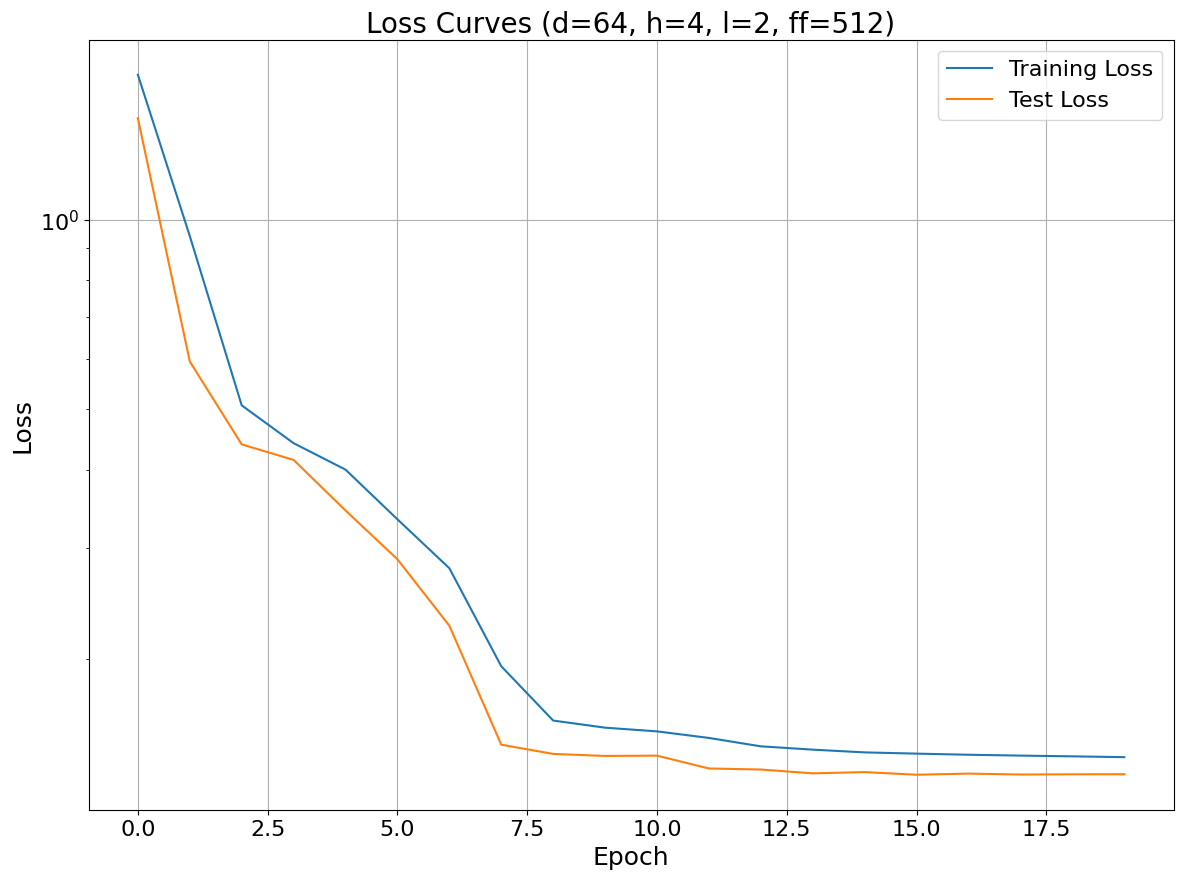

In [14]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
    )

BIOMASS_Ec_iML1515_core_75p37M:
------------------------------------------------------------
Plotting flux 'BIOMASS_Ec_iML1515_core_75p37M' (column index 2702)
BIOMASS_Ec_iML1515_core_75p37M y_true range: 2.644315004348755 .. 3.0259485244750977
BIOMASS_Ec_iML1515_core_75p37M y_pred range: 2.7116987705230713 .. 2.7830967903137207


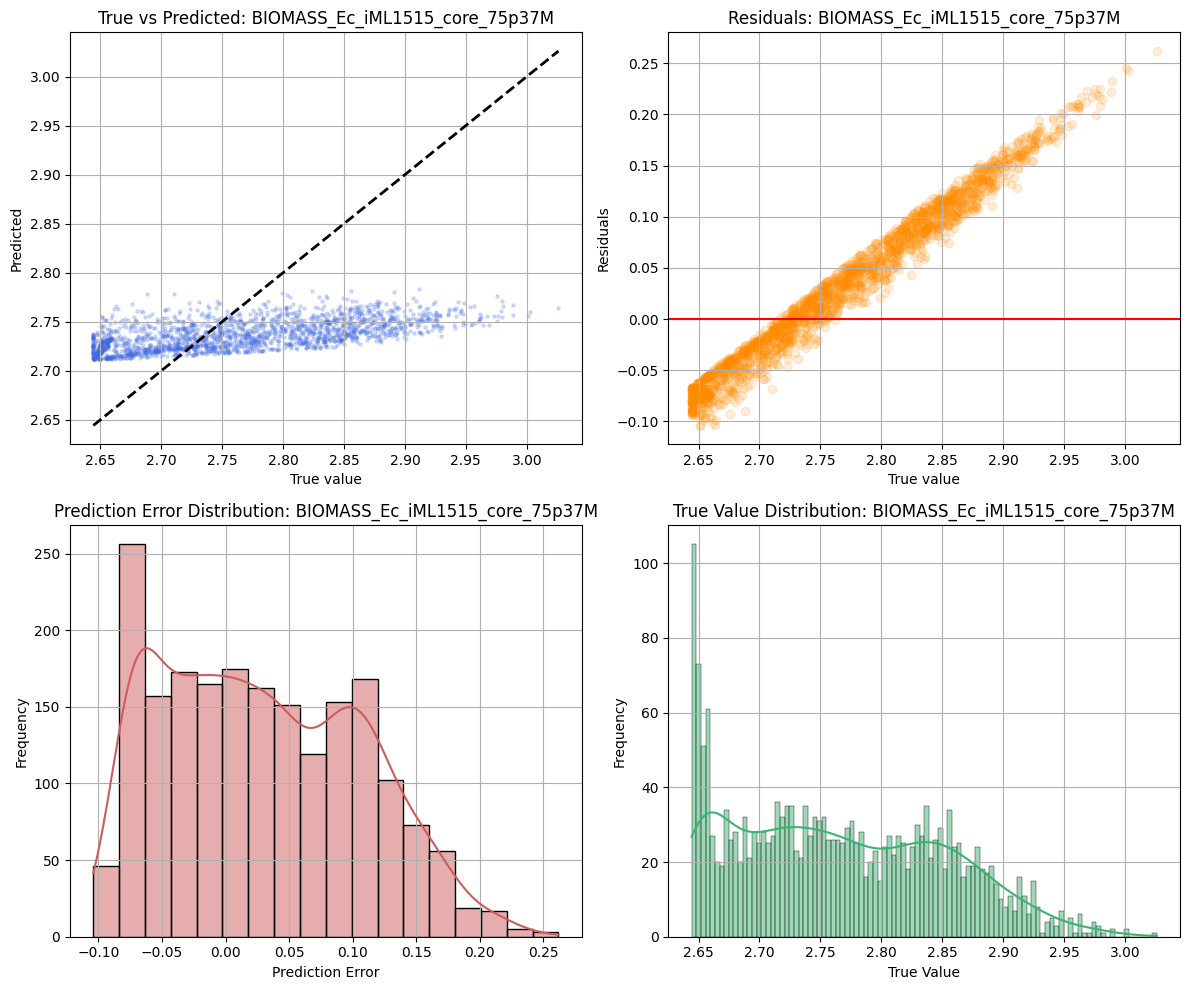

In [15]:
diagnostics_to_plot = ['BIOMASS_Ec_iML1515_core_75p37M']#, 'GLUDy', 'H2Ot_flux', 'SUCCt3_flux', 'GLUN_flux', 'PGM_flux']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png")